In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, f1_score, classification_report

In [2]:
columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv("wdbc.data", header=None, names=columns)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 32)


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
print("Number of Samples:", df.shape[0])
print("Number of Features:", df.shape[1] - 2)

print("\nTarget Classes:")
print(df["Diagnosis"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nClass Distribution (%):")
print((df["Diagnosis"].value_counts(normalize=True) * 100).round(2))

Number of Samples: 569
Number of Features: 30

Target Classes:
Diagnosis
B    357
M    212
Name: count, dtype: int64

Missing Values:
0

Class Distribution (%):
Diagnosis
B    62.74
M    37.26
Name: proportion, dtype: float64


In [4]:
X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"].map({"B": 0, "M": 1})

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nEncoded Classes:")
print(y.value_counts())

Feature Shape: (569, 30)
Target Shape: (569,)

Encoded Classes:
Diagnosis
0    357
1    212
Name: count, dtype: int64


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

Training Samples: 455
Testing Samples: 114


In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Data Shape:", X_train_scaled.shape)
print("Testing Data Shape:", X_test_scaled.shape)

print("\nFirst 5 Standardized Features:")
print(X_train_scaled[:5, :5])

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)

First 5 Standardized Features:
[[ 0.51855873  0.89182579  0.4246317   0.38392544 -0.97474371]
 [-0.51636409 -1.63971029 -0.54134872 -0.54296133  0.47621906]
 [-0.36811839  0.45551496 -0.38824993 -0.40297004 -1.43297929]
 [ 0.20528479  0.72616767  0.40033031  0.0706116   0.24325348]
 [ 1.2430047   0.19419511  1.21037678  1.20665201 -0.11144185]]


In [7]:
pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(X_train_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Total Original Features:", X_train_scaled.shape[1])
print("Components Needed for 95% Variance:", components_95)
print("Explained Variance:", round(cumulative_variance[components_95 - 1] * 100, 2), "%")

Total Original Features: 30
Components Needed for 95% Variance: 10
Explained Variance: 95.21 %


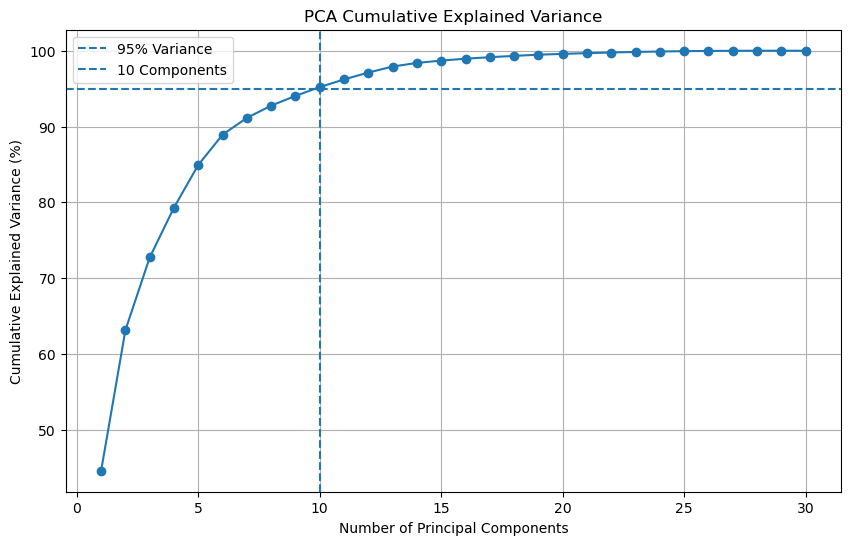

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance * 100,
    marker="o"
)

plt.axhline(
    y=95,
    linestyle="--",
    label="95% Variance"
)

plt.axvline(
    x=components_95,
    linestyle="--",
    label=f"{components_95} Components"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance (%)")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.grid()
plt.show()

In [9]:
pca = PCA(n_components=components_95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Original Feature Count:", X_train_scaled.shape[1])
print("Reduced Feature Count:", X_train_pca.shape[1])

print("\nOriginal Training Shape:", X_train_scaled.shape)
print("PCA Training Shape:", X_train_pca.shape)

print("\nOriginal Testing Shape:", X_test_scaled.shape)
print("PCA Testing Shape:", X_test_pca.shape)

Original Feature Count: 30
Reduced Feature Count: 10

Original Training Shape: (455, 30)
PCA Training Shape: (455, 10)

Original Testing Shape: (114, 30)
PCA Testing Shape: (114, 10)


In [10]:
pca_summary = pd.DataFrame({
    "Setting": ["With-PCA"],
    "Chosen Components / Variance Target": [
        f"{components_95} components / 95%"
    ],
    "Explained Variance (%)": [
        round(pca.explained_variance_ratio_.sum() * 100, 2)
    ],
    "Justification": [
        "Reduced dimensionality while retaining at least 95% of the original variance."
    ]
})

pca_summary

,Setting,Chosen Components / Variance Target,Explained Variance (%),Justification
0,With-PCA,10 components / 95%,95.21,Reduced dimensionality while retaining at leas...


In [11]:
from sklearn.svm import SVC

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

svm_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("svm", SVC())
])

svm_params = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.1, 1],
    "svm__kernel": ["linear", "rbf"]
}

print("SVM pipelines and hyperparameter grid created.")

SVM pipelines and hyperparameter grid created.


In [12]:
svm_grid_no_pca = GridSearchCV(
    svm_no_pca,
    svm_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

svm_grid_no_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(svm_grid_no_pca.best_params_)

print("\nBest 5-Fold F1 Score (No-PCA):")
print(round(svm_grid_no_pca.best_score_, 4))

Best Parameters (No-PCA):
{'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}

Best 5-Fold F1 Score (No-PCA):
0.9674


In [13]:
svm_grid_pca = GridSearchCV(
    svm_pca,
    svm_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

svm_grid_pca.fit(X_train, y_train)

print("Best Parameters (With-PCA):")
print(svm_grid_pca.best_params_)

print("\nBest 5-Fold F1 Score (With-PCA):")
print(round(svm_grid_pca.best_score_, 4))

Best Parameters (With-PCA):
{'svm__C': 1, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}

Best 5-Fold F1 Score (With-PCA):
0.9644


In [14]:
svm_results = pd.DataFrame({
    "Kernel": ["linear, rbf"],
    "C Values Tried": ["0.1, 1, 10, 100"],
    "Gamma Values Tried": ["scale, 0.01, 0.1, 1"],
    "Best Performance (No-PCA)": [round(svm_grid_no_pca.best_score_, 4)],
    "Best Performance (With-PCA)": [round(svm_grid_pca.best_score_, 4)]
})

svm_results

,Kernel,C Values Tried,Gamma Values Tried,Best Performance (No-PCA),Best Performance (With-PCA)
0,"linear, rbf","0.1, 1, 10, 100","scale, 0.01, 0.1, 1",0.9674,0.9644


In [15]:
from sklearn.naive_bayes import GaussianNB

nb_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("nb", GaussianNB())
])

nb_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("nb", GaussianNB())
])

nb_params = {
    "nb__var_smoothing": [1e-11, 1e-10, 1e-9, 1e-8, 1e-7]
}

nb_grid_no_pca = GridSearchCV(
    nb_no_pca,
    nb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

nb_grid_pca = GridSearchCV(
    nb_pca,
    nb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

nb_grid_no_pca.fit(X_train, y_train)
nb_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(nb_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(nb_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(nb_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(nb_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'nb__var_smoothing': 1e-11}

Best F1 Score (No-PCA):
0.917

Best Parameters (With-PCA):
{'nb__var_smoothing': 1e-11}

Best F1 Score (With-PCA):
0.8824


In [16]:
nb_tuning_results = []

for alpha in nb_params["nb__var_smoothing"]:
    no_pca_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("nb", GaussianNB(var_smoothing=alpha))
        ])

        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = model.predict(X_train.iloc[val_idx])

        no_pca_scores.append(
            f1_score(y_train.iloc[val_idx], pred)
        )

    pca_scores = []

    for train_idx, val_idx in cv.split(X_train, y_train):
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=components_95)),
            ("nb", GaussianNB(var_smoothing=alpha))
        ])

        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        pred = model.predict(X_train.iloc[val_idx])

        pca_scores.append(
            f1_score(y_train.iloc[val_idx], pred)
        )

    nb_tuning_results.append([
        alpha,
        round(np.mean(no_pca_scores), 4),
        round(np.mean(pca_scores), 4)
    ])

nb_results = pd.DataFrame(
    nb_tuning_results,
    columns=[
        "Smoothing Parameter",
        "Performance (No-PCA)",
        "Performance (With-PCA)"
    ]
)

nb_results

,Smoothing Parameter,Performance (No-PCA),Performance (With-PCA)
0,1.000000e-11,0.917,0.8824
1,1.000000e-10,0.917,0.8824
2,1.000000e-09,0.917,0.8824
3,1.000000e-08,0.917,0.8824
4,1.000000e-07,0.917,0.8824


In [17]:
from sklearn.neighbors import KNeighborsClassifier

knn_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

knn_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("knn", KNeighborsClassifier())
])

knn_params = {
    "knn__n_neighbors": [3, 5, 7, 9, 11],
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

print("KNN hyperparameter grid created.")

KNN hyperparameter grid created.


In [18]:
knn_grid_no_pca = GridSearchCV(
    knn_no_pca,
    knn_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

knn_grid_pca = GridSearchCV(
    knn_pca,
    knn_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

knn_grid_no_pca.fit(X_train, y_train)
knn_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(knn_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(knn_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(knn_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(knn_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}

Best F1 Score (No-PCA):
0.9667

Best Parameters (With-PCA):
{'knn__metric': 'euclidean', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}

Best F1 Score (With-PCA):
0.9605


In [19]:
knn_no_pca_results = pd.DataFrame(knn_grid_no_pca.cv_results_)

knn_pca_results = pd.DataFrame(knn_grid_pca.cv_results_)

knn_table = pd.DataFrame({
    "k": knn_no_pca_results["param_knn__n_neighbors"],
    "Weights": knn_no_pca_results["param_knn__weights"],
    "Distance Metric": knn_no_pca_results["param_knn__metric"],
    "Performance (No-PCA)": knn_no_pca_results["mean_test_score"].round(4),
    "Performance (With-PCA)": knn_pca_results["mean_test_score"].round(4)
})

knn_table = knn_table.sort_values(
    by="Performance (No-PCA)",
    ascending=False
).reset_index(drop=True)

knn_table

,k,Weights,Distance Metric,Performance (No-PCA),Performance (With-PCA)
0,3,distance,manhattan,0.9667,0.9485
1,3,uniform,manhattan,0.9667,0.9485
2,3,uniform,euclidean,0.9633,0.9605
3,3,distance,euclidean,0.9633,0.9605
4,5,distance,manhattan,0.9631,0.9491
5,5,uniform,manhattan,0.9631,0.9491
6,7,distance,euclidean,0.9605,0.9542
7,7,uniform,euclidean,0.9575,0.9509
8,7,distance,manhattan,0.9536,0.9516
9,5,uniform,euclidean,0.9510,0.9543


In [20]:
from sklearn.linear_model import LogisticRegression

log_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(max_iter=5000))
])

log_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("logreg", LogisticRegression(max_iter=5000))
])

log_params = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__solver": ["liblinear", "lbfgs"]
}

print("Logistic Regression hyperparameter grid created.")

Logistic Regression hyperparameter grid created.


In [21]:
log_grid_no_pca = GridSearchCV(
    log_no_pca,
    log_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

log_grid_pca = GridSearchCV(
    log_pca,
    log_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

log_grid_no_pca.fit(X_train, y_train)
log_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(log_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(log_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(log_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(log_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'logreg__C': 1, 'logreg__solver': 'liblinear'}

Best F1 Score (No-PCA):
0.964

Best Parameters (With-PCA):
{'logreg__C': 0.1, 'logreg__solver': 'liblinear'}

Best F1 Score (With-PCA):
0.9701


In [22]:
log_no_pca_results = pd.DataFrame(log_grid_no_pca.cv_results_)
log_pca_results = pd.DataFrame(log_grid_pca.cv_results_)

log_table = pd.DataFrame({
    "C": log_no_pca_results["param_logreg__C"],
    "Solver": log_no_pca_results["param_logreg__solver"],
    "Performance (No-PCA)": log_no_pca_results["mean_test_score"].round(4),
    "Performance (With-PCA)": log_pca_results["mean_test_score"].round(4)
})

log_table = log_table.sort_values(
    by="Performance (No-PCA)",
    ascending=False
).reset_index(drop=True)

log_table

,C,Solver,Performance (No-PCA),Performance (With-PCA)
0,1.00,liblinear,0.9640,0.9671
1,1.00,lbfgs,0.9640,0.9671
2,0.10,liblinear,0.9637,0.9701
3,0.10,lbfgs,0.9603,0.9572
4,10.00,liblinear,0.9581,0.9614
5,0.01,liblinear,0.9551,0.9555
6,10.00,lbfgs,0.9550,0.9642
7,100.00,liblinear,0.9472,0.9642
8,100.00,lbfgs,0.9472,0.9642
9,0.01,lbfgs,0.9234,0.9269


In [23]:
print("Logistic Regression Summary")
print("-" * 35)
print("No-PCA Best F1  :", round(log_grid_no_pca.best_score_, 4))
print("With-PCA Best F1:", round(log_grid_pca.best_score_, 4))
print("Difference      :", round(
    log_grid_pca.best_score_ - log_grid_no_pca.best_score_, 4
))

Logistic Regression Summary
-----------------------------------
No-PCA Best F1  : 0.964
With-PCA Best F1: 0.9701
Difference      : 0.0061


In [24]:
from sklearn.tree import DecisionTreeClassifier

dt_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("dt", DecisionTreeClassifier(random_state=42))
])

dt_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("dt", DecisionTreeClassifier(random_state=42))
])

dt_params = {
    "dt__criterion": ["gini", "entropy"],
    "dt__max_depth": [None, 3, 5, 7, 10],
    "dt__min_samples_split": [2, 5, 10]
}

print("Decision Tree hyperparameter grid created.")

Decision Tree hyperparameter grid created.


In [25]:
dt_grid_no_pca = GridSearchCV(
    dt_no_pca,
    dt_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

dt_grid_pca = GridSearchCV(
    dt_pca,
    dt_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

dt_grid_no_pca.fit(X_train, y_train)
dt_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(dt_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(dt_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(dt_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(dt_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'dt__criterion': 'entropy', 'dt__max_depth': 5, 'dt__min_samples_split': 10}

Best F1 Score (No-PCA):
0.9039

Best Parameters (With-PCA):
{'dt__criterion': 'gini', 'dt__max_depth': 5, 'dt__min_samples_split': 10}

Best F1 Score (With-PCA):
0.9107


In [26]:
dt_no_pca_results = pd.DataFrame(dt_grid_no_pca.cv_results_)
dt_pca_results = pd.DataFrame(dt_grid_pca.cv_results_)

dt_table = pd.DataFrame({
    "Criterion": dt_no_pca_results["param_dt__criterion"],
    "Max Depth": dt_no_pca_results["param_dt__max_depth"],
    "Min Samples Split": dt_no_pca_results["param_dt__min_samples_split"],
    "Performance (No-PCA)": dt_no_pca_results["mean_test_score"].round(4),
    "Performance (With-PCA)": dt_pca_results["mean_test_score"].round(4)
})

dt_table = dt_table.sort_values(
    by="Performance (No-PCA)",
    ascending=False
).reset_index(drop=True)

dt_table

,Criterion,Max Depth,Min Samples Split,Performance (No-PCA),Performance (With-PCA)
0,entropy,5,10,0.9039,0.8909
1,entropy,None,10,0.9012,0.8963
2,entropy,10,10,0.9012,0.8963
3,entropy,7,10,0.9012,0.8963
4,gini,7,5,0.8969,0.8916
5,gini,None,2,0.8962,0.8926
6,gini,7,2,0.8962,0.8926
7,gini,10,2,0.8962,0.8926
8,entropy,None,5,0.8962,0.8969
9,entropy,10,5,0.8962,0.8969


In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(random_state=42))
])

rf_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("rf", RandomForestClassifier(random_state=42))
])

rf_params = {
    "rf__n_estimators": [50, 100, 200],
    "rf__max_depth": [None, 5, 10],
    "rf__min_samples_split": [2, 5],
    "rf__max_features": ["sqrt", "log2"]
}

print("Random Forest hyperparameter grid created.")

Random Forest hyperparameter grid created.


In [28]:
rf_grid_no_pca = GridSearchCV(
    rf_no_pca,
    rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_grid_pca = GridSearchCV(
    rf_pca,
    rf_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

rf_grid_no_pca.fit(X_train, y_train)
rf_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(rf_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(rf_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(rf_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(rf_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'rf__max_depth': 10, 'rf__max_features': 'log2', 'rf__min_samples_split': 2, 'rf__n_estimators': 200}

Best F1 Score (No-PCA):
0.9557

Best Parameters (With-PCA):
{'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_split': 2, 'rf__n_estimators': 200}

Best F1 Score (With-PCA):
0.943


In [29]:
rf_no_pca_results = pd.DataFrame(rf_grid_no_pca.cv_results_)
rf_pca_results = pd.DataFrame(rf_grid_pca.cv_results_)

rf_table = pd.DataFrame({
    "N Estimators": rf_no_pca_results["param_rf__n_estimators"],
    "Max Depth": rf_no_pca_results["param_rf__max_depth"],
    "Min Samples Split": rf_no_pca_results["param_rf__min_samples_split"],
    "Max Features": rf_no_pca_results["param_rf__max_features"],
    "Performance (No-PCA)": rf_no_pca_results["mean_test_score"].round(4),
    "Performance (With-PCA)": rf_pca_results["mean_test_score"].round(4)
})

rf_table = rf_table.sort_values(
    by="Performance (No-PCA)",
    ascending=False
).reset_index(drop=True)

rf_table

,N Estimators,Max Depth,Min Samples Split,Max Features,Performance (No-PCA),Performance (With-PCA)
0,200,10,2,log2,0.9557,0.9398
1,100,5,2,sqrt,0.9553,0.9272
2,100,None,2,log2,0.9529,0.9371
3,100,10,2,log2,0.9529,0.9344
4,100,None,5,log2,0.9528,0.9338
5,100,10,5,log2,0.9528,0.9338
6,200,None,2,log2,0.9526,0.9430
7,100,None,2,sqrt,0.9519,0.9371
8,100,10,2,sqrt,0.9519,0.9344
9,100,5,5,log2,0.9492,0.9306


In [30]:
from sklearn.ensemble import AdaBoostClassifier

ada_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("ada", AdaBoostClassifier(random_state=42))
])

ada_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("ada", AdaBoostClassifier(random_state=42))
])

ada_params = {
    "ada__n_estimators": [50, 100, 200],
    "ada__learning_rate": [0.01, 0.1, 0.5, 1.0]
}

print("AdaBoost hyperparameter grid created.")

AdaBoost hyperparameter grid created.


In [31]:
ada_grid_no_pca = GridSearchCV(
    ada_no_pca,
    ada_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

ada_grid_pca = GridSearchCV(
    ada_pca,
    ada_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

ada_grid_no_pca.fit(X_train, y_train)
ada_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(ada_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(ada_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(ada_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(ada_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'ada__learning_rate': 0.5, 'ada__n_estimators': 200}

Best F1 Score (No-PCA):
0.9612

Best Parameters (With-PCA):
{'ada__learning_rate': 1.0, 'ada__n_estimators': 100}

Best F1 Score (With-PCA):
0.9605


In [32]:
ada_no_pca_results = pd.DataFrame(ada_grid_no_pca.cv_results_)
ada_pca_results = pd.DataFrame(ada_grid_pca.cv_results_)

ada_table = pd.DataFrame({
    "N Estimators": ada_no_pca_results["param_ada__n_estimators"],
    "Learning Rate": ada_no_pca_results["param_ada__learning_rate"],
    "Performance (No-PCA)": ada_no_pca_results["mean_test_score"].round(4),
    "Performance (With-PCA)": ada_pca_results["mean_test_score"].round(4)
})

ada_table = ada_table.sort_values(
    by="Performance (No-PCA)",
    ascending=False
).reset_index(drop=True)

ada_table

,N Estimators,Learning Rate,Performance (No-PCA),Performance (With-PCA)
0,200,0.50,0.9612,0.9485
1,200,1.00,0.9610,0.9575
2,100,0.50,0.9607,0.9550
3,50,1.00,0.9546,0.9588
4,200,0.10,0.9542,0.9294
5,100,1.00,0.9523,0.9605
6,50,0.50,0.9512,0.9379
7,100,0.10,0.9455,0.9097
8,50,0.10,0.9336,0.9008
9,200,0.01,0.9015,0.8695


In [33]:
from sklearn.ensemble import GradientBoostingClassifier

gb_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("gb", GradientBoostingClassifier(random_state=42))
])

gb_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("gb", GradientBoostingClassifier(random_state=42))
])

gb_params = {
    "gb__n_estimators": [50, 100, 200],
    "gb__learning_rate": [0.01, 0.1, 0.2],
    "gb__max_depth": [2, 3, 5]
}

print("Gradient Boosting hyperparameter grid created.")

Gradient Boosting hyperparameter grid created.


In [34]:
gb_grid_no_pca = GridSearchCV(
    gb_no_pca,
    gb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

gb_grid_pca = GridSearchCV(
    gb_pca,
    gb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

gb_grid_no_pca.fit(X_train, y_train)
gb_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(gb_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(gb_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(gb_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(gb_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'gb__learning_rate': 0.1, 'gb__max_depth': 2, 'gb__n_estimators': 200}

Best F1 Score (No-PCA):
0.9645

Best Parameters (With-PCA):
{'gb__learning_rate': 0.2, 'gb__max_depth': 2, 'gb__n_estimators': 100}

Best F1 Score (With-PCA):
0.943


In [35]:
gb_no_pca_results = pd.DataFrame(gb_grid_no_pca.cv_results_)
gb_pca_results = pd.DataFrame(gb_grid_pca.cv_results_)

gb_table = pd.DataFrame({
    "N Estimators": gb_no_pca_results["param_gb__n_estimators"],
    "Learning Rate": gb_no_pca_results["param_gb__learning_rate"],
    "Max Depth": gb_no_pca_results["param_gb__max_depth"],
    "Performance (No-PCA)": gb_no_pca_results["mean_test_score"].round(4),
    "Performance (With-PCA)": gb_pca_results["mean_test_score"].round(4)
})

gb_table = gb_table.sort_values(
    by="Performance (No-PCA)",
    ascending=False
).reset_index(drop=True)

gb_table

,N Estimators,Learning Rate,Max Depth,Performance (No-PCA),Performance (With-PCA)
0,200,0.10,2,0.9645,0.9331
1,100,0.20,2,0.9644,0.9430
2,200,0.20,2,0.9641,0.9405
3,50,0.20,2,0.9583,0.9276
4,200,0.10,3,0.9582,0.9283
5,100,0.10,3,0.9553,0.9298
6,100,0.10,2,0.9551,0.9339
7,50,0.20,3,0.9550,0.9363
8,200,0.20,3,0.9548,0.9374
9,100,0.20,3,0.9546,0.9310


In [36]:
from xgboost import XGBClassifier

xgb_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("xgb", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("xgb", XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_params = {
    "xgb__n_estimators": [50, 100, 200],
    "xgb__max_depth": [2, 3, 5],
    "xgb__learning_rate": [0.01, 0.1, 0.2]
}

print("XGBoost hyperparameter grid created.")

XGBoost hyperparameter grid created.


In [38]:
xgb_grid_no_pca = GridSearchCV(
    xgb_no_pca,
    xgb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

xgb_grid_pca = GridSearchCV(
    xgb_pca,
    xgb_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

xgb_grid_no_pca.fit(X_train, y_train)
xgb_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(xgb_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(xgb_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(xgb_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(xgb_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'xgb__learning_rate': 0.2, 'xgb__max_depth': 2, 'xgb__n_estimators': 50}

Best F1 Score (No-PCA):
0.9671

Best Parameters (With-PCA):
{'xgb__learning_rate': 0.2, 'xgb__max_depth': 5, 'xgb__n_estimators': 100}

Best F1 Score (With-PCA):
0.9673


In [39]:
xgb_no_pca_results = pd.DataFrame(xgb_grid_no_pca.cv_results_)
xgb_pca_results = pd.DataFrame(xgb_grid_pca.cv_results_)

xgb_table = pd.DataFrame({
    "N Estimators": xgb_no_pca_results["param_xgb__n_estimators"],
    "Max Depth": xgb_no_pca_results["param_xgb__max_depth"],
    "Learning Rate": xgb_no_pca_results["param_xgb__learning_rate"],
    "Performance (No-PCA)": xgb_no_pca_results["mean_test_score"].round(4),
    "Performance (With-PCA)": xgb_pca_results["mean_test_score"].round(4)
})

xgb_table = xgb_table.sort_values(
    by="Performance (No-PCA)",
    ascending=False
).reset_index(drop=True)

xgb_table

,N Estimators,Max Depth,Learning Rate,Performance (No-PCA),Performance (With-PCA)
0,50,2,0.20,0.9671,0.9440
1,200,2,0.20,0.9645,0.9583
2,200,3,0.20,0.9645,0.9554
3,200,2,0.10,0.9643,0.9524
4,100,3,0.20,0.9643,0.9554
5,50,3,0.20,0.9643,0.9549
6,100,2,0.20,0.9643,0.9524
7,200,5,0.10,0.9615,0.9642
8,100,3,0.10,0.9614,0.9522
9,200,3,0.10,0.9614,0.9554


In [40]:
from sklearn.ensemble import StackingClassifier

stack_estimators = [
    ("svm", SVC(probability=True, C=1, kernel="rbf")),
    ("lr", LogisticRegression(max_iter=5000, C=1)),
    ("rf", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
]

stack_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("stack", StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(max_iter=5000),
        cv=5
    ))
])

stack_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=components_95)),
    ("stack", StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(max_iter=5000),
        cv=5
    ))
])

stack_params = {
    "stack__final_estimator__C": [0.1, 1, 10]
}

print("Stacking model and hyperparameter grid created.")

Stacking model and hyperparameter grid created.


In [41]:
stack_grid_no_pca = GridSearchCV(
    stack_no_pca,
    stack_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

stack_grid_pca = GridSearchCV(
    stack_pca,
    stack_params,
    cv=cv,
    scoring="f1",
    n_jobs=-1
)

stack_grid_no_pca.fit(X_train, y_train)
stack_grid_pca.fit(X_train, y_train)

print("Best Parameters (No-PCA):")
print(stack_grid_no_pca.best_params_)

print("\nBest F1 Score (No-PCA):")
print(round(stack_grid_no_pca.best_score_, 4))

print("\nBest Parameters (With-PCA):")
print(stack_grid_pca.best_params_)

print("\nBest F1 Score (With-PCA):")
print(round(stack_grid_pca.best_score_, 4))

Best Parameters (No-PCA):
{'stack__final_estimator__C': 1}

Best F1 Score (No-PCA):
0.9702

Best Parameters (With-PCA):
{'stack__final_estimator__C': 1}

Best F1 Score (With-PCA):
0.9762


In [42]:
stack_no_pca_results = pd.DataFrame(stack_grid_no_pca.cv_results_)
stack_pca_results = pd.DataFrame(stack_grid_pca.cv_results_)

stack_table = pd.DataFrame({
    "Meta-Learner C": stack_no_pca_results[
        "param_stack__final_estimator__C"
    ],
    "Performance (No-PCA)": stack_no_pca_results[
        "mean_test_score"
    ].round(4),
    "Performance (With-PCA)": stack_pca_results[
        "mean_test_score"
    ].round(4)
})

stack_table

,Meta-Learner C,Performance (No-PCA),Performance (With-PCA)
0,0.1,0.9638,0.9635
1,1.0,0.9702,0.9762
2,10.0,0.9672,0.9733


In [43]:
best_models_no_pca = {
    "SVM": svm_grid_no_pca.best_estimator_,
    "Naive Bayes": nb_grid_no_pca.best_estimator_,
    "KNN": knn_grid_no_pca.best_estimator_,
    "Logistic Regression": log_grid_no_pca.best_estimator_,
    "Decision Tree": dt_grid_no_pca.best_estimator_,
    "Random Forest": rf_grid_no_pca.best_estimator_,
    "AdaBoost": ada_grid_no_pca.best_estimator_,
    "Gradient Boosting": gb_grid_no_pca.best_estimator_,
    "XGBoost": xgb_grid_no_pca.best_estimator_,
    "Stacking": stack_grid_no_pca.best_estimator_
}

best_models_pca = {
    "SVM": svm_grid_pca.best_estimator_,
    "Naive Bayes": nb_grid_pca.best_estimator_,
    "KNN": knn_grid_pca.best_estimator_,
    "Logistic Regression": log_grid_pca.best_estimator_,
    "Decision Tree": dt_grid_pca.best_estimator_,
    "Random Forest": rf_grid_pca.best_estimator_,
    "AdaBoost": ada_grid_pca.best_estimator_,
    "Gradient Boosting": gb_grid_pca.best_estimator_,
    "XGBoost": xgb_grid_pca.best_estimator_,
    "Stacking": stack_grid_pca.best_estimator_
}

print("All 10 tuned models stored successfully.")

All 10 tuned models stored successfully.


In [44]:
from sklearn.model_selection import cross_val_score

cv_results = []

for model_name in best_models_no_pca.keys():

    no_pca_scores = cross_val_score(
        best_models_no_pca[model_name],
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    pca_scores = cross_val_score(
        best_models_pca[model_name],
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append([
        model_name,
        *np.round(no_pca_scores, 4),
        round(no_pca_scores.mean(), 4),
        *np.round(pca_scores, 4),
        round(pca_scores.mean(), 4)
    ])

print("5-fold cross-validation completed.")

5-fold cross-validation completed.


In [45]:
cv_table = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "No-PCA Fold 1",
        "No-PCA Fold 2",
        "No-PCA Fold 3",
        "No-PCA Fold 4",
        "No-PCA Fold 5",
        "Avg (No-PCA)",
        "With-PCA Fold 1",
        "With-PCA Fold 2",
        "With-PCA Fold 3",
        "With-PCA Fold 4",
        "With-PCA Fold 5",
        "Avg (With-PCA)"
    ]
)

cv_table

,Model,No-PCA Fold 1,No-PCA Fold 2,No-PCA Fold 3,No-PCA Fold 4,No-PCA Fold 5,Avg (No-PCA),With-PCA Fold 1,With-PCA Fold 2,With-PCA Fold 3,With-PCA Fold 4,With-PCA Fold 5,Avg (With-PCA)
0,SVM,0.9538,0.9855,0.9565,0.9706,0.9706,0.9674,0.9394,0.9565,0.9714,0.9697,0.9851,0.9644
1,Naive Bayes,0.9375,0.9714,0.8857,0.8788,0.9118,0.9170,0.8710,0.9697,0.8529,0.8197,0.8986,0.8824
2,KNN,0.9552,1.0000,0.9538,0.9394,0.9851,0.9667,0.9697,0.9706,0.9375,0.9394,0.9851,0.9605
3,Logistic Regression,0.9375,0.9565,1.0000,0.9697,0.9565,0.9640,0.9697,0.9565,0.9697,0.9697,0.9851,0.9701
4,Decision Tree,0.8657,0.9275,0.8750,0.9118,0.9394,0.9039,0.8955,0.9565,0.9118,0.8485,0.9412,0.9107
5,Random Forest,0.9552,0.9714,0.9394,0.9429,0.9697,0.9557,0.9538,0.9714,0.9412,0.9091,0.9394,0.9430
6,AdaBoost,0.9538,0.9565,0.9538,0.9565,0.9851,0.9612,0.9206,0.9851,0.9706,0.9412,0.9851,0.9605
7,Gradient Boosting,0.9552,0.9706,0.9552,0.9565,0.9851,0.9645,0.9231,0.9577,0.9412,0.9394,0.9538,0.9430
8,XGBoost,0.9697,0.9706,0.9538,0.9565,0.9851,0.9671,0.9538,0.9714,0.9565,0.9851,0.9697,0.9673
9,Stacking,0.9231,0.9714,1.0000,0.9697,0.9706,0.9670,0.9697,0.9565,1.0000,0.9697,0.9851,0.9762


In [46]:
comparison_table = cv_table[
    ["Model", "Avg (No-PCA)", "Avg (With-PCA)"]
].copy()

comparison_table["PCA Change"] = (
    comparison_table["Avg (With-PCA)"] -
    comparison_table["Avg (No-PCA)"]
).round(4)

comparison_table["PCA Effect"] = comparison_table["PCA Change"].apply(
    lambda x: "Improved" if x > 0 else ("Decreased" if x < 0 else "No Change")
)

comparison_table

,Model,Avg (No-PCA),Avg (With-PCA),PCA Change,PCA Effect
0,SVM,0.9674,0.9644,-0.0030,Decreased
1,Naive Bayes,0.9170,0.8824,-0.0346,Decreased
2,KNN,0.9667,0.9605,-0.0062,Decreased
3,Logistic Regression,0.9640,0.9701,0.0061,Improved
4,Decision Tree,0.9039,0.9107,0.0068,Improved
5,Random Forest,0.9557,0.9430,-0.0127,Decreased
6,AdaBoost,0.9612,0.9605,-0.0007,Decreased
7,Gradient Boosting,0.9645,0.9430,-0.0215,Decreased
8,XGBoost,0.9671,0.9673,0.0002,Improved
9,Stacking,0.9670,0.9762,0.0092,Improved


In [47]:
test_results = []

for model_name in best_models_no_pca.keys():

    no_pca_model = best_models_no_pca[model_name]
    pca_model = best_models_pca[model_name]

    no_pca_model.fit(X_train, y_train)
    pca_model.fit(X_train, y_train)

    no_pca_pred = no_pca_model.predict(X_test)
    pca_pred = pca_model.predict(X_test)

    no_pca_accuracy = accuracy_score(y_test, no_pca_pred)
    no_pca_f1 = f1_score(y_test, no_pca_pred)

    pca_accuracy = accuracy_score(y_test, pca_pred)
    pca_f1 = f1_score(y_test, pca_pred)

    test_results.append([
        model_name,
        round(no_pca_accuracy, 4),
        round(no_pca_f1, 4),
        round(pca_accuracy, 4),
        round(pca_f1, 4)
    ])

test_results

[['SVM', 0.9737, 0.963, 0.9649, 0.9512],
 ['Naive Bayes', 0.9211, 0.8889, 0.8947, 0.8571],
 ['KNN', 0.9649, 0.95, 0.9474, 0.925],
 ['Logistic Regression', 0.9737, 0.9639, 0.9825, 0.9756],
 ['Decision Tree', 0.9561, 0.9383, 0.9386, 0.9136],
 ['Random Forest', 0.9561, 0.9367, 0.9474, 0.9268],
 ['AdaBoost', 0.9737, 0.963, 0.9649, 0.9512],
 ['Gradient Boosting', 0.9649, 0.95, 0.9561, 0.9383],
 ['XGBoost', 0.9649, 0.95, 0.9737, 0.9639],
 ['Stacking', 0.9912, 0.988, 0.9825, 0.9756]]

In [48]:
test_table = pd.DataFrame(
    test_results,
    columns=[
        "Model",
        "Accuracy (No-PCA)",
        "F1 (No-PCA)",
        "Accuracy (With-PCA)",
        "F1 (With-PCA)"
    ]
)

test_table

,Model,Accuracy (No-PCA),F1 (No-PCA),Accuracy (With-PCA),F1 (With-PCA)
0,SVM,0.9737,0.9630,0.9649,0.9512
1,Naive Bayes,0.9211,0.8889,0.8947,0.8571
2,KNN,0.9649,0.9500,0.9474,0.9250
3,Logistic Regression,0.9737,0.9639,0.9825,0.9756
4,Decision Tree,0.9561,0.9383,0.9386,0.9136
5,Random Forest,0.9561,0.9367,0.9474,0.9268
6,AdaBoost,0.9737,0.9630,0.9649,0.9512
7,Gradient Boosting,0.9649,0.9500,0.9561,0.9383
8,XGBoost,0.9649,0.9500,0.9737,0.9639
9,Stacking,0.9912,0.9880,0.9825,0.9756


In [49]:
final_comparison = test_table.copy()

final_comparison["Accuracy Change"] = (
    final_comparison["Accuracy (With-PCA)"] -
    final_comparison["Accuracy (No-PCA)"]
).round(4)

final_comparison["F1 Change"] = (
    final_comparison["F1 (With-PCA)"] -
    final_comparison["F1 (No-PCA)"]
).round(4)

final_comparison

,Model,Accuracy (No-PCA),F1 (No-PCA),Accuracy (With-PCA),F1 (With-PCA),Accuracy Change,F1 Change
0,SVM,0.9737,0.9630,0.9649,0.9512,-0.0088,-0.0118
1,Naive Bayes,0.9211,0.8889,0.8947,0.8571,-0.0264,-0.0318
2,KNN,0.9649,0.9500,0.9474,0.9250,-0.0175,-0.0250
3,Logistic Regression,0.9737,0.9639,0.9825,0.9756,0.0088,0.0117
4,Decision Tree,0.9561,0.9383,0.9386,0.9136,-0.0175,-0.0247
5,Random Forest,0.9561,0.9367,0.9474,0.9268,-0.0087,-0.0099
6,AdaBoost,0.9737,0.9630,0.9649,0.9512,-0.0088,-0.0118
7,Gradient Boosting,0.9649,0.9500,0.9561,0.9383,-0.0088,-0.0117
8,XGBoost,0.9649,0.9500,0.9737,0.9639,0.0088,0.0139
9,Stacking,0.9912,0.9880,0.9825,0.9756,-0.0087,-0.0124


In [50]:
best_no_pca = test_table.loc[
    test_table["F1 (No-PCA)"].idxmax()
]

best_pca = test_table.loc[
    test_table["F1 (With-PCA)"].idxmax()
]

print("Best No-PCA Model:")
print(best_no_pca)

print("\nBest With-PCA Model:")
print(best_pca)

Best No-PCA Model:
Model                  Stacking
Accuracy (No-PCA)        0.9912
F1 (No-PCA)               0.988
Accuracy (With-PCA)      0.9825
F1 (With-PCA)            0.9756
Name: 9, dtype: object

Best With-PCA Model:
Model                  Logistic Regression
Accuracy (No-PCA)                   0.9737
F1 (No-PCA)                         0.9639
Accuracy (With-PCA)                 0.9825
F1 (With-PCA)                       0.9756
Name: 3, dtype: object


In [51]:
final_table = cv_table[
    ["Model", "Avg (No-PCA)", "Avg (With-PCA)"]
].copy()

final_table = final_table.merge(
    test_table[
        [
            "Model",
            "Accuracy (No-PCA)",
            "F1 (No-PCA)",
            "Accuracy (With-PCA)",
            "F1 (With-PCA)"
        ]
    ],
    on="Model"
)

final_table["CV F1 Change"] = (
    final_table["Avg (With-PCA)"] -
    final_table["Avg (No-PCA)"]
).round(4)

final_table

,Model,Avg (No-PCA),Avg (With-PCA),Accuracy (No-PCA),F1 (No-PCA),Accuracy (With-PCA),F1 (With-PCA),CV F1 Change
0,SVM,0.9674,0.9644,0.9737,0.9630,0.9649,0.9512,-0.0030
1,Naive Bayes,0.9170,0.8824,0.9211,0.8889,0.8947,0.8571,-0.0346
2,KNN,0.9667,0.9605,0.9649,0.9500,0.9474,0.9250,-0.0062
3,Logistic Regression,0.9640,0.9701,0.9737,0.9639,0.9825,0.9756,0.0061
4,Decision Tree,0.9039,0.9107,0.9561,0.9383,0.9386,0.9136,0.0068
5,Random Forest,0.9557,0.9430,0.9561,0.9367,0.9474,0.9268,-0.0127
6,AdaBoost,0.9612,0.9605,0.9737,0.9630,0.9649,0.9512,-0.0007
7,Gradient Boosting,0.9645,0.9430,0.9649,0.9500,0.9561,0.9383,-0.0215
8,XGBoost,0.9671,0.9673,0.9649,0.9500,0.9737,0.9639,0.0002
9,Stacking,0.9670,0.9762,0.9912,0.9880,0.9825,0.9756,0.0092


In [52]:
best_model = final_table.loc[
    final_table["F1 (No-PCA)"].idxmax()
]

print("Overall Best Model:")
print(best_model["Model"])

print("Test Accuracy:", best_model["Accuracy (No-PCA)"])
print("Test F1 Score:", best_model["F1 (No-PCA)"])

Overall Best Model:
Stacking
Test Accuracy: 0.9912
Test F1 Score: 0.988


In [53]:
selected_models = {
    "Stacking (No-PCA)": best_models_no_pca["Stacking"],
    "Logistic Regression (With-PCA)": best_models_pca["Logistic Regression"],
    "XGBoost (With-PCA)": best_models_pca["XGBoost"]
}

selected_predictions = {}
selected_probabilities = {}

for name, model in selected_models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    selected_predictions[name] = predictions
    selected_probabilities[name] = probabilities

print("Selected models trained successfully.")

Selected models trained successfully.


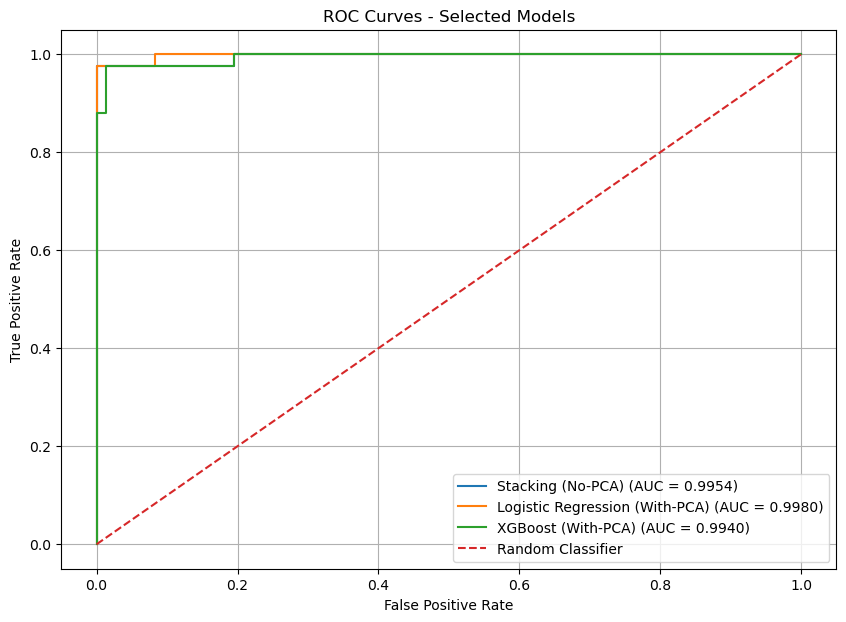

In [54]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 7))

for name in selected_models.keys():

    fpr, tpr, _ = roc_curve(
        y_test,
        selected_probabilities[name]
    )

    auc_score = roc_auc_score(
        y_test,
        selected_probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Selected Models")
plt.legend()
plt.grid()
plt.show()

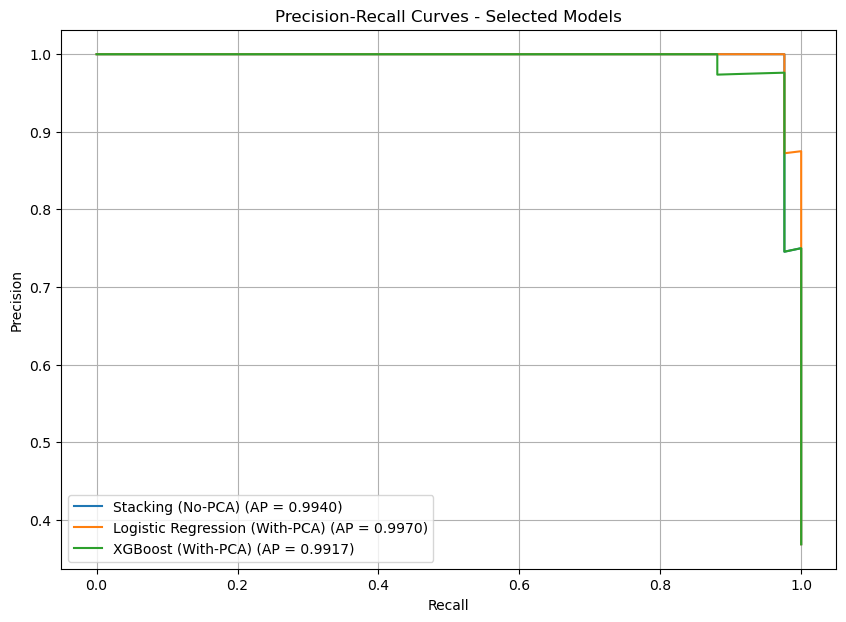

In [55]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for name in selected_models.keys():

    precision, recall, _ = precision_recall_curve(
        y_test,
        selected_probabilities[name]
    )

    ap_score = average_precision_score(
        y_test,
        selected_probabilities[name]
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap_score:.4f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Selected Models")
plt.legend()
plt.grid()
plt.show()

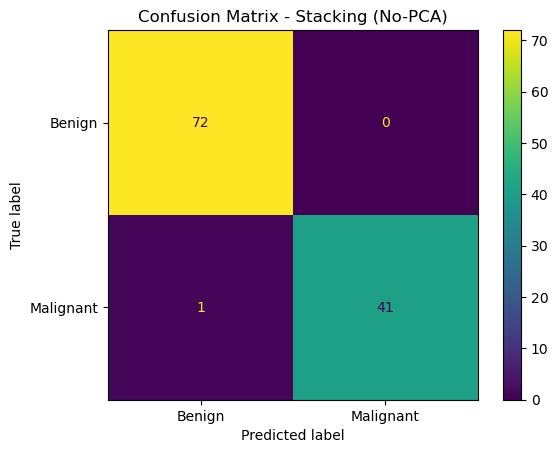

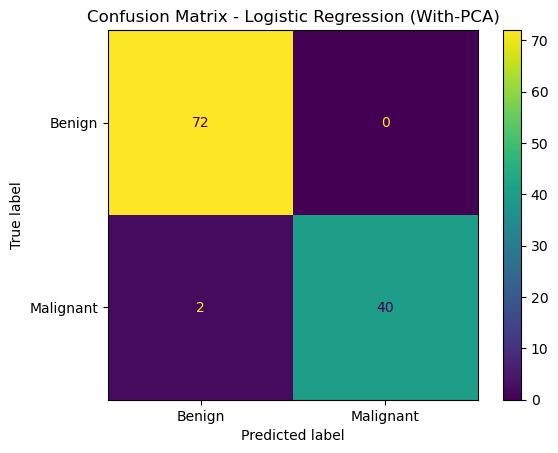

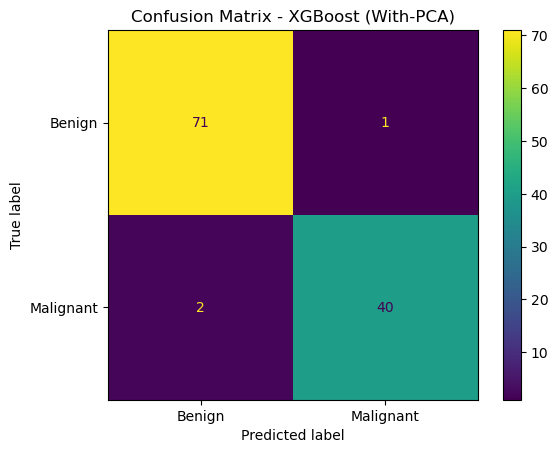

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name in selected_models.keys():

    cm = confusion_matrix(
        y_test,
        selected_predictions[name]
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    )

    display.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [57]:
curve_results = []

for name in selected_models.keys():

    auc_score = roc_auc_score(
        y_test,
        selected_probabilities[name]
    )

    ap_score = average_precision_score(
        y_test,
        selected_probabilities[name]
    )

    curve_results.append([
        name,
        round(auc_score, 4),
        round(ap_score, 4)
    ])

curve_table = pd.DataFrame(
    curve_results,
    columns=[
        "Model",
        "ROC-AUC",
        "Average Precision (AP)"
    ]
)

curve_table

,Model,ROC-AUC,Average Precision (AP)
0,Stacking (No-PCA),0.9954,0.9940
1,Logistic Regression (With-PCA),0.9980,0.9970
2,XGBoost (With-PCA),0.9940,0.9917
